In [1]:
import math
import sys
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path().resolve()))

from src.data.nu_classifier_dataset import NuClassifierExpNpyDataset
from src.data.nu_classifier_dataset.collate import nu_classifier_collate_fn

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total events in DB:        12,061,961
After blacklist (no c4):   9,936,157  (removed 2,125,804 cluster-4 events)
  No cuts     : 9,936,157 events  |  score>0.8:  43,750  (0.440%)
  SN ≥8-2     : 6,614,853 events  |  score>0.8:  31,324  (0.474%)
  SN ≥10-3    : 4,197,567 events  |  score>0.8:  21,118  (0.503%)


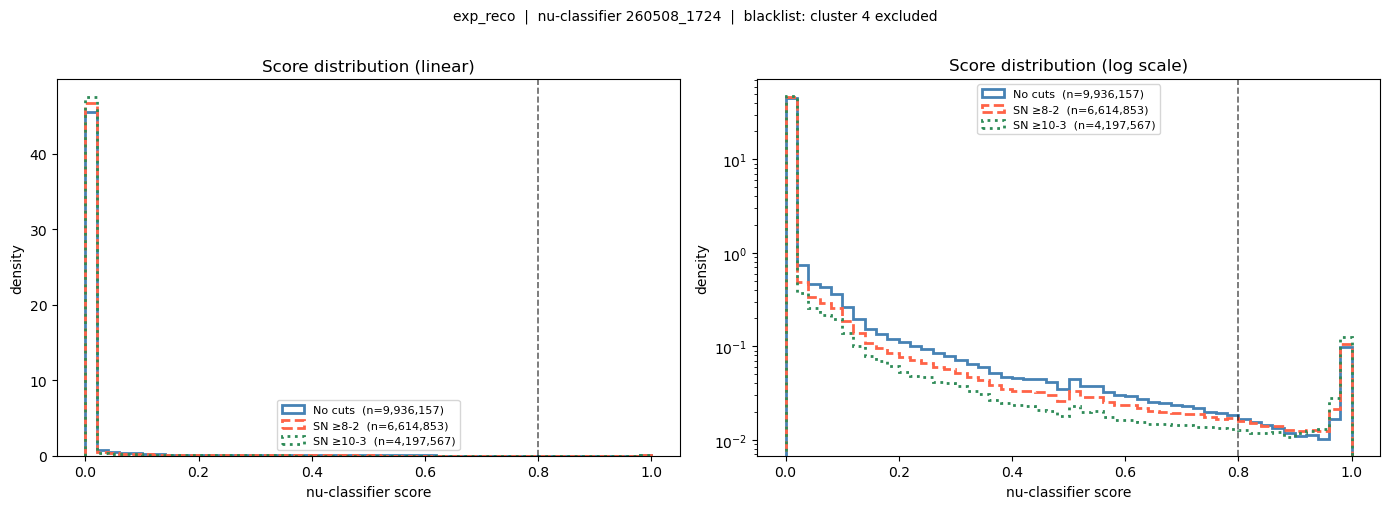

In [1]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt

DB  = "inference_v2/nu_classifier/preds/260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32@best_da_model/exp_reco_thr0p8.duckdb"
CAT = "data_manager/catalog_v2.duckdb"

conn = duckdb.connect(DB, read_only=True)
conn.execute(f"ATTACH '{CAT}' AS cat (READ_ONLY)")

# Pull score + cluster in one join (1–2 s)
df = conn.execute("""
    SELECT p.score, p.n_sn_hits, p.n_sn_strings, e.cluster
    FROM predictions p
    JOIN cat.events e ON e.id = p.event_fk
""").df()

conn.execute("DETACH cat")
conn.close()

print(f"Total events in DB:        {len(df):,}")

# ── Blacklist: exclude cluster 4 (channel 71 broken across entire cluster) ──
# channel 198 broken in part_s2020_c04_r0117 is a subset of cluster 4 → already covered
df_bl = df[df.cluster != 4].copy()
print(f"After blacklist (no c4):   {len(df_bl):,}  "
      f"(removed {len(df)-len(df_bl):,} cluster-4 events)")

# ── Three cut levels ──────────────────────────────────────────────────
cuts = {
    "No cuts":  df_bl,
    "SN ≥8-2":  df_bl[(df_bl.n_sn_hits >= 8)  & (df_bl.n_sn_strings >= 2)],
    "SN ≥10-3": df_bl[(df_bl.n_sn_hits >= 10) & (df_bl.n_sn_strings >= 3)],
}

for label, sub in cuts.items():
    hi = (sub.score > 0.8).sum()
    print(f"  {label:12s}: {len(sub):>9,} events  |  score>0.8: {hi:>7,}  ({100*hi/len(sub):.3f}%)")

# ── Plot ──────────────────────────────────────────────────────────────
bins   = np.linspace(0, 1, 51)
colors = ["steelblue", "tomato", "seagreen"]
styles = ["-", "--", ":"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    for (label, sub), color, ls in zip(cuts.items(), colors, styles):
        ax.hist(sub.score, bins=bins, density=True,
                histtype="step", linewidth=2,
                color=color, linestyle=ls,
                label=f"{label}  (n={len(sub):,})")
    ax.axvline(0.8, color="black", lw=1.2, ls="--", alpha=0.6)
    ax.set_xlabel("nu-classifier score")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

axes[1].set_yscale("log")
axes[0].set_title("Score distribution (linear)")
axes[1].set_title("Score distribution (log scale)")

plt.suptitle(
    "exp_reco  |  nu-classifier 260508_1724  |  blacklist: cluster 4 excluded",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

In [2]:
EXP_BG_NPY_DIR = (
    "inference_v2/nu_classifier/exp_finetuning/exp_bg_datasets/"
    "260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32@best_da_model_lt0p1"
)
N_EVENTS = 5
SEED     = 42
MAX_HITS = 500

# From finetuned checkpoint: ckpt["normalization_config"]
NORM_CONFIG = {
    "means": [2.0,  0.0,  0.0, 0.0,   0.0],
    "stds":  [60.0, 1370.0, 40.0, 40.0, 150.0],
}
AUG_CONFIG = {
    "rotation_enabled": True,
    "noise_std": [0.05, 5.0, 1.0, 1.0, 2.0],   # in original-feature units
}
FEATURE_NAMES = ["Q", "t", "x", "y", "z"]

In [3]:
ds = NuClassifierExpNpyDataset(
    npy_dir=EXP_BG_NPY_DIR,
    max_hits=MAX_HITS,
    max_events=N_EVENTS,
    seed=SEED,
    prefix="exp_bg",
)
events = [ds[i] for i in range(N_EVENTS)]

for i, ev in enumerate(events):
    print(f"Event {i}: {ev['features'].shape[0]} sig-hits  "
          f"(original {ev['original_lengths'].item()})")

Event 0: 12 sig-hits  (original 12)
Event 1: 5 sig-hits  (original 5)
Event 2: 7 sig-hits  (original 7)
Event 3: 17 sig-hits  (original 17)
Event 4: 8 sig-hits  (original 8)


In [4]:
# ── helper: step-2 augmentation as in exp_finetuning_trainer _augment() ──

def _augment_legacy(features: torch.Tensor, mask: torch.Tensor) -> tuple:
    """Legacy (pre-fix): noise_std applied directly to normalized features.
    Values like 5.0 for time blow up in normalized space (~unit scale).
    Also no input validation.
    """
    features = features.clone()
    bs = features.shape[0]

    if AUG_CONFIG.get("rotation_enabled"):
        angles = torch.rand(bs) * 2 * math.pi
        cos_a, sin_a = torch.cos(angles), torch.sin(angles)
        x = features[:, :, 2].clone()
        y = features[:, :, 3].clone()
        features[:, :, 2] = torch.where(mask, cos_a[:, None] * x - sin_a[:, None] * y, features[:, :, 2])
        features[:, :, 3] = torch.where(mask, sin_a[:, None] * x + cos_a[:, None] * y, features[:, :, 3])

    noise_std = torch.tensor(AUG_CONFIG["noise_std"], dtype=torch.float32)   # raw original-space std!
    noise = torch.randn_like(features) * noise_std
    features = torch.where(mask.unsqueeze(-1), features + noise, features)

    time_sort = features[:, :, 1].masked_fill(~mask, float("inf"))
    idx = time_sort.argsort(dim=1)
    features = features.gather(1, idx.unsqueeze(-1).expand_as(features))
    mask     = mask.gather(1, idx)
    return features, mask


def _augment_current(features: torch.Tensor, mask: torch.Tensor) -> tuple:
    """Current (fixed): noise_std / norm_stds so noise is correct in normalized space."""
    features = features.clone()
    bs = features.shape[0]

    if AUG_CONFIG.get("rotation_enabled"):
        angles = torch.rand(bs) * 2 * math.pi
        cos_a, sin_a = torch.cos(angles), torch.sin(angles)
        x = features[:, :, 2].clone()
        y = features[:, :, 3].clone()
        features[:, :, 2] = torch.where(mask, cos_a[:, None] * x - sin_a[:, None] * y, features[:, :, 2])
        features[:, :, 3] = torch.where(mask, sin_a[:, None] * x + cos_a[:, None] * y, features[:, :, 3])

    norm_stds = torch.tensor(NORM_CONFIG["stds"], dtype=torch.float32)
    noise_std = torch.tensor(AUG_CONFIG["noise_std"], dtype=torch.float32) / norm_stds
    noise = torch.randn_like(features) * noise_std
    features = torch.where(mask.unsqueeze(-1), features + noise, features)

    time_sort = features[:, :, 1].masked_fill(~mask, float("inf"))
    idx = time_sort.argsort(dim=1)
    features = features.gather(1, idx.unsqueeze(-1).expand_as(features))
    mask     = mask.gather(1, idx)
    return features, mask

In [5]:
torch.manual_seed(SEED)

# ── Strategy 1: Legacy ────────────────────────────────────────────────────
# collate: aug in original space → normalize  (noise_std correct here)
# _augment: SAME noise_std applied to normalized features (wrong scale)
collate_legacy = partial(
    nu_classifier_collate_fn,
    normalization_config=NORM_CONFIG,
    augmentation_config=AUG_CONFIG,   # aug before norm — original-space noise
    shuffle_batch=False,
    device="cpu",
)
batch_l = collate_legacy(events)
feat_l, mask_l = _augment_legacy(batch_l["features"], batch_l["mask"])

# ── Strategy 2: Current ───────────────────────────────────────────────────
# collate: normalize only (no aug)
# _augment: noise_std / norm_stds — correct scale in normalized space
collate_current = partial(
    nu_classifier_collate_fn,
    normalization_config=NORM_CONFIG,
    augmentation_config=None,         # no aug in collate
    shuffle_batch=False,
    device="cpu",
)
batch_c = collate_current(events)
feat_c, mask_c = _augment_current(batch_c["features"], batch_c["mask"])

# ── Baseline: normalize only, no augmentation ─────────────────────────────
feat_n = batch_c["features"].clone()
mask_n = batch_c["mask"].clone()

print("Noise std in normalized space (legacy vs current):")
norm_stds = torch.tensor(NORM_CONFIG["stds"])
ns_raw    = torch.tensor(AUG_CONFIG["noise_std"])
for fname, ns, ns_scaled in zip(FEATURE_NAMES, ns_raw, ns_raw / norm_stds):
    print(f"  {fname:3s}: legacy={ns:.4f}  current={ns_scaled:.6f}")

Noise std in normalized space (legacy vs current):
  Q  : legacy=0.0500  current=0.000833
  t  : legacy=5.0000  current=0.003650
  x  : legacy=1.0000  current=0.025000
  y  : legacy=1.0000  current=0.025000
  z  : legacy=2.0000  current=0.013333


/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


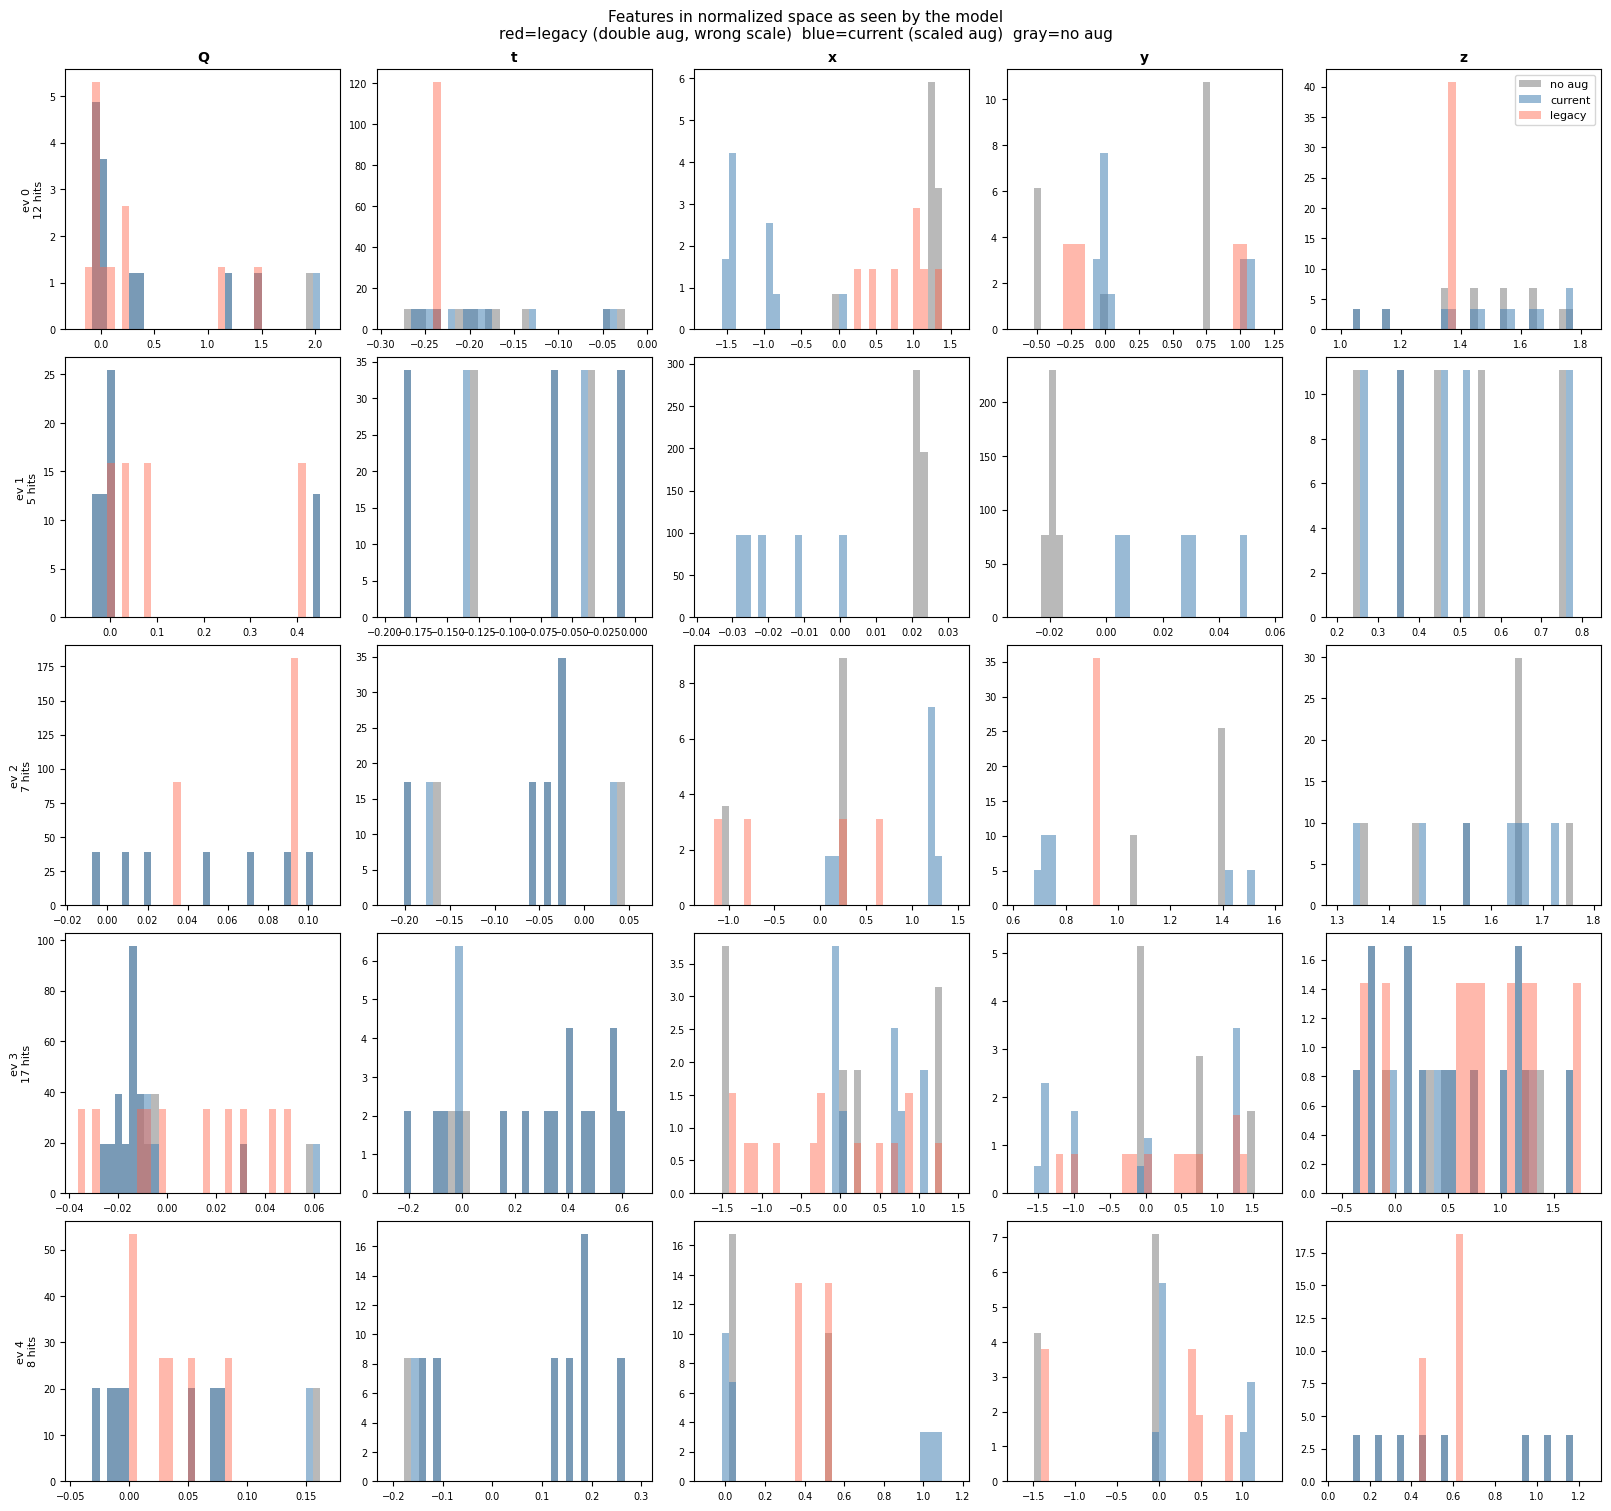

In [6]:
fig, axes = plt.subplots(
    N_EVENTS, len(FEATURE_NAMES),
    figsize=(16, 3 * N_EVENTS),
    constrained_layout=True,
)
fig.suptitle(
    "Features in normalized space as seen by the model\n"
    "red=legacy (double aug, wrong scale)  blue=current (scaled aug)  gray=no aug",
    fontsize=11,
)

for ev in range(N_EVENTS):
    n_hits = int(mask_n[ev].sum().item())
    for f in range(len(FEATURE_NAMES)):
        ax = axes[ev, f]

        v_n = feat_n[ev, mask_n[ev], f].numpy()
        v_l = feat_l[ev, mask_l[ev], f].numpy()
        v_c = feat_c[ev, mask_c[ev], f].numpy()

        # clip range to union of current + baseline (legacy can be extreme)
        lo = min(np.percentile(v_n, 1), np.percentile(v_c, 1))
        hi = max(np.percentile(v_n, 99), np.percentile(v_c, 99))
        span = max(hi - lo, 0.1)
        lo -= 0.1 * span
        hi += 0.1 * span
        bins = np.linspace(lo, hi, 35)

        ax.hist(v_n, bins=bins, color="gray",  alpha=0.55, density=True, label="no aug")
        ax.hist(v_c, bins=bins, color="steelblue", alpha=0.55, density=True, label="current")
        ax.hist(v_l, bins=bins, color="tomato",    alpha=0.45, density=True, label="legacy")

        if ev == 0:
            ax.set_title(FEATURE_NAMES[f], fontsize=10, fontweight="bold")
        if f == 0:
            ax.set_ylabel(f"ev {ev}\n{n_hits} hits", fontsize=8)
        ax.tick_params(labelsize=7)

axes[0, -1].legend(fontsize=8, loc="upper right")
plt.savefig("compare_aug_strategies.png", dpi=110, bbox_inches="tight")
plt.show()

In [8]:
# Summary: effective noise magnitude in normalized space per feature
print("Effective noise_std in normalized space:")
print(f"{'feature':>8}  {'original_std':>14}  {'noise (legacy)':>16}  {'noise (current)':>17}  {'ratio':>7}")
for fname, orig_std, ns in zip(FEATURE_NAMES, NORM_CONFIG["stds"], AUG_CONFIG["noise_std"]):
    legacy_ns  = ns                  # applied directly to ~unit-scale normalized features
    current_ns = ns / orig_std
    print(f"{fname:>8}  {orig_std:>14.1f}  {legacy_ns:>16.4f}  {current_ns:>17.6f}  {legacy_ns/current_ns:>7.0f}×")

Effective noise_std in normalized space:
 feature    original_std    noise (legacy)    noise (current)    ratio
       Q            60.0            0.0500           0.000833       60×
       t          1370.0            5.0000           0.003650     1370×
       x            40.0            1.0000           0.025000       40×
       y            40.0            1.0000           0.025000       40×
       z           150.0            2.0000           0.013333      150×
